<a href="https://colab.research.google.com/github/MinCOnMinCon/Who-sThatPokemon/blob/main/Who'sThatPokemon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
# Streamlit 설치 (-q는 설치 로그를 숨겨 깔끔하게 보여줍니다)
!pip install -q streamlit

# 웹 페이지를 외부로 열어줄 localtunnel 설치
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 128.2 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
added 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
!unzip -q "/content/drive/MyDrive/archive.zip" -d "/content/pokemon_dataset"

In [8]:
!pip install -q split-folders


In [9]:
import splitfolders
input_dir = "/content/pokemon_dataset/PokemonData"
output_dir = "/content/pokemon_split_set"
splitfolders.ratio(input_dir, output=output_dir, seed=42, ratio=(0.8, 0.2))


Copying files: 6837 files [00:03, 2104.73 files/s]


In [10]:
from tqdm.auto import tqdm

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, accuracy_score,f1_score
import numpy as np
import os

# ==========================================
# 1. 하이퍼파라미터 및 환경 설정
# ==========================================
# 실험 번호를 1, 2, 3, 4로 변경하며 실행하십시오.
EXPERIMENT_TYPE = 4
NUM_CLASSES = 150
BATCH_SIZE = 32
NUM_EPOCHS = 10
DATA_DIR = '/content/pokemon_split_set' # 실제 데이터셋 경로로 변경해야 합니다.

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 디바이스: {device}")

# ==========================================
# 2. 데이터 전처리 및 로더 설정
# ==========================================
# ImageNet 사전 학습 모델을 위한 표준 정규화 수치 사용
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# ImageFolder를 사용하여 데이터셋 로드 (데이터셋이 train/val 폴더로 나뉘어 있다고 가정)
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=(x=='train'), num_workers=0)
               for x in ['train', 'val']}

# ==========================================
# 3. 모델 설정 함수 (파인튜닝 범위 제어)
# ==========================================
def create_model(exp_type, num_classes):
    model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)

    # 먼저 모든 파라미터의 기울기 계산을 비활성화(Freeze)
    for param in model.parameters():
        param.requires_grad = False

    # 실험 타입에 따른 동결 해제(Unfreeze)
    for name, param in model.named_parameters():
        if exp_type == 1:
            # 분류기(fc)만 학습
            if 'fc' in name:
                param.requires_grad = True
        elif exp_type == 2:
            # inception5b와 fc 학습
            if 'inception5b' in name or 'fc' in name:
                param.requires_grad = True
        elif exp_type == 3:
            # inception5a, inception5b, fc 학습
            if 'inception5a' in name or 'inception5b' in name or 'fc' in name:
                param.requires_grad = True
        elif exp_type == 4:
            # 전체 모델 학습
            param.requires_grad = True

    # 마지막 분류기 층 교체 (포켓몬 클래스 개수에 맞춤)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    return model

# ==========================================
# 4. 모델, 손실 함수, 옵티마이저 초기화
# ==========================================
#for EXPERIMENT_TYPE in range(1,5):
print(f"실험 {EXPERIMENT_TYPE} 시작")
model = create_model(EXPERIMENT_TYPE, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# requires_grad가 True인 파라미터만 학습기에 전달
params_to_update = [p for p in model.parameters() if p.requires_grad]

# 실험 4(전체 파인튜닝)의 경우 기존 가중치 보존을 위해 학습률을 낮춤
learning_rate = 0.0001 if EXPERIMENT_TYPE == 4 else 0.001
optimizer = optim.Adam(params_to_update, lr=learning_rate)

# ==========================================
# 5. 학습 및 검증 루프
# ==========================================
for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        all_preds = []
        all_labels = []

        for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase.capitalize()} 진행중", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)

                # 모델이 튜플(보조 분류기 포함)을 반환하든, 단일 텐서를 반환하든 무조건 메인 결과만 빼옵니다.
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)

                _, preds = torch.max(outputs, 1)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = running_loss / len(image_datasets[phase])

        # 검증(Validation) 단계에서 성능 지표 계산
        if phase == 'val':
            # average='macro'는 클래스 불균형이 있을 때 각 클래스의 지표를 평균 냅니다.
            acc = accuracy_score(all_labels, all_preds)
            precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
            recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
            f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)


            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} | Acc: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1_Score: {f1:.4f}')
        else:
            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f}')

print('학습이 완료되었습니다.')

# 모델 저장 (선택 사항)
torch.save(model.state_dict(), f'googlenet_exp{EXPERIMENT_TYPE}.pth')

현재 사용 중인 디바이스: cuda:0
실험 4 시작
Epoch 1/10
----------


Train 진행중:   0%|          | 0/169 [00:00<?, ?it/s]

Train Loss: 4.4761


Val 진행중:   0%|          | 0/45 [00:00<?, ?it/s]

Val Loss: 3.4780 | Acc: 0.6066 | Precision: 0.6679 | Recall: 0.5833 | F1_Score: 0.5627
Epoch 2/10
----------


...

Val Loss: 0.2455 | Acc: 0.9523 | Precision: 0.9572 | Recall: 0.9510 | F1_Score: 0.9501
Epoch 10/10
----------


Train 진행중:   0%|          | 0/169 [00:00<?, ?it/s]

Train Loss: 0.0616


Val 진행중:   0%|          | 0/45 [00:00<?, ?it/s]

Val Loss: 0.2298 | Acc: 0.9530 | Precision: 0.9571 | Recall: 0.9519 | F1_Score: 0.9516
학습이 완료되었습니다.


In [14]:
import json

# 파이토치 데이터셋이 인식한 150개 클래스(폴더명) 리스트 출력
class_list = image_datasets['train'].classes
print(json.dumps(class_list))

["Abra", "Aerodactyl", "Alakazam", "Alolan Sandslash", "Arbok", "Arcanine", "Articuno", "Beedrill", "Bellsprout", "Blastoise", "Bulbasaur", "Butterfree", "Caterpie", "Chansey", "Charizard", "Charmander", "Charmeleon", "Clefable", "Clefairy", "Cloyster", "Cubone", "Dewgong", "Diglett", "Ditto", "Dodrio", "Doduo", "Dragonair", "Dragonite", "Dratini", "Drowzee", "Dugtrio", "Eevee", "Ekans", "Electabuzz", "Electrode", "Exeggcute", "Exeggutor", "Farfetchd", "Fearow", "Flareon", "Gastly", "Gengar", "Geodude", "Gloom", "Golbat", "Goldeen", "Golduck", "Golem", "Graveler", "Grimer", "Growlithe", "Gyarados", "Haunter", "Hitmonchan", "Hitmonlee", "Horsea", "Hypno", "Ivysaur", "Jigglypuff", "Jolteon", "Jynx", "Kabuto", "Kabutops", "Kadabra", "Kakuna", "Kangaskhan", "Kingler", "Koffing", "Krabby", "Lapras", "Lickitung", "Machamp", "Machoke", "Machop", "Magikarp", "Magmar", "Magnemite", "Magneton", "Mankey", "Marowak", "Meowth", "Metapod", "Mew", "Mewtwo", "Moltres", "MrMime", "Muk", "Nidoking", "Ni

In [30]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

# --- 페이지 설정 ---
st.set_page_config(page_title="Pokemon Classifier", page_icon="🐾")
st.title("포켓몬 분류기 🐾")
st.write("이미지를 업로드하면 어떤 포켓몬인지 예측합니다.")

# --- 클래스 이름 설정 (여기에 복사한 리스트를 붙여넣으세요!) ---
CLASS_NAMES = [
   "Abra", "Aerodactyl", "Alakazam", "Alolan Sandslash", "Arbok", "Arcanine", "Articuno", "Beedrill", "Bellsprout", "Blastoise", "Bulbasaur", "Butterfree", "Caterpie", "Chansey", "Charizard", "Charmander", "Charmeleon", "Clefable", "Clefairy", "Cloyster", "Cubone", "Dewgong", "Diglett", "Ditto", "Dodrio", "Doduo", "Dragonair", "Dragonite", "Dratini", "Drowzee", "Dugtrio", "Eevee", "Ekans", "Electabuzz", "Electrode", "Exeggcute", "Exeggutor", "Farfetchd", "Fearow", "Flareon", "Gastly", "Gengar", "Geodude", "Gloom", "Golbat", "Goldeen", "Golduck", "Golem", "Graveler", "Grimer", "Growlithe", "Gyarados", "Haunter", "Hitmonchan", "Hitmonlee", "Horsea", "Hypno", "Ivysaur", "Jigglypuff", "Jolteon", "Jynx", "Kabuto", "Kabutops", "Kadabra", "Kakuna", "Kangaskhan", "Kingler", "Koffing", "Krabby", "Lapras", "Lickitung", "Machamp", "Machoke", "Machop", "Magikarp", "Magmar", "Magnemite", "Magneton", "Mankey", "Marowak", "Meowth", "Metapod", "Mew", "Mewtwo", "Moltres", "MrMime", "Muk", "Nidoking", "Nidoqueen", "Nidorina", "Nidorino", "Ninetales", "Oddish", "Omanyte", "Omastar", "Onix", "Paras", "Parasect", "Persian", "Pidgeot", "Pidgeotto", "Pidgey", "Pikachu", "Pinsir", "Poliwag", "Poliwhirl", "Poliwrath", "Ponyta", "Porygon", "Primeape", "Psyduck", "Raichu", "Rapidash", "Raticate", "Rattata", "Rhydon", "Rhyhorn", "Sandshrew", "Sandslash", "Scyther", "Seadra", "Seaking", "Seel", "Shellder", "Slowbro", "Slowpoke", "Snorlax", "Spearow", "Squirtle", "Starmie", "Staryu", "Tangela", "Tauros", "Tentacool", "Tentacruel", "Vaporeon", "Venomoth", "Venonat", "Venusaur", "Victreebel", "Vileplume", "Voltorb", "Vulpix", "Wartortle", "Weedle", "Weepinbell", "Weezing", "Wigglytuff", "Zapdos", "Zubat"
]

# --- 모델 로드 함수 ---
@st.cache_resource
def load_model():
    device = torch.device("cpu")
    model = models.googlenet(weights=None, aux_logits = True)
    model.fc = nn.Linear(model.fc.in_features, 150)

    model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, 150)
    model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, 150)
    # 주의: 학습이 완료되어 저장된 가중치 파일 이름으로 변경하세요.
    try:
        model.load_state_dict(torch.load('googlenet_exp4.pth', map_location=device), strict = False)
        model.eval()
        return model, device
    except FileNotFoundError:
        st.error("모델 가중치 파일('googlenet_exp1.pth')을 찾을 수 없습니다. 학습이 완료되었는지 확인해주세요.")
        return None, None

model, device = load_model()

# --- 이미지 전처리 ---
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- UI: 이미지 업로드 및 추론 ---
if model:
    uploaded_file = st.file_uploader("포켓몬 이미지를 선택하세요 (jpg, png, jpeg)", type=["jpg", "png", "jpeg"])

    if uploaded_file is not None:
        image = Image.open(uploaded_file).convert('RGB')
        st.image(image, caption='업로드된 이미지', use_column_width=True)

        with st.spinner("포켓몬 도감 검색 중..."):
            img_tensor = preprocess(image).unsqueeze(0).to(device)

            with torch.no_grad():
              outputs = model(img_tensor)
              probabilities = F.softmax(outputs, dim=1)
              # 가장 높은 확률 1개만 추출
              prob, idx = torch.max(probabilities, 1)


        st.success("분류 완료!")

        confidence = prob.item() * 100
        pokemon_name = CLASS_NAMES[idx.item()]

        # 큰 글씨와 강조 색상으로 결과 표시
        st.markdown(f"### 이 포켓몬은... **{pokemon_name}** 입니다!")
        st.write(f"**예측 신뢰도:** {confidence:.2f}%")

Overwriting app.py


In [31]:
# 2. 보안 접속용 비밀번호(외부 IP) 확인
import urllib
print("===========================================")
print("접속 비밀번호(IP):", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))
print("===========================================")

# 3. Streamlit 백그라운드 실행 및 터널링 오픈
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

접속 비밀번호(IP): 136.118.236.48
⠙⠹⠸⠼⠴⠦your url is: https://shaky-ways-melt.loca.lt
^C


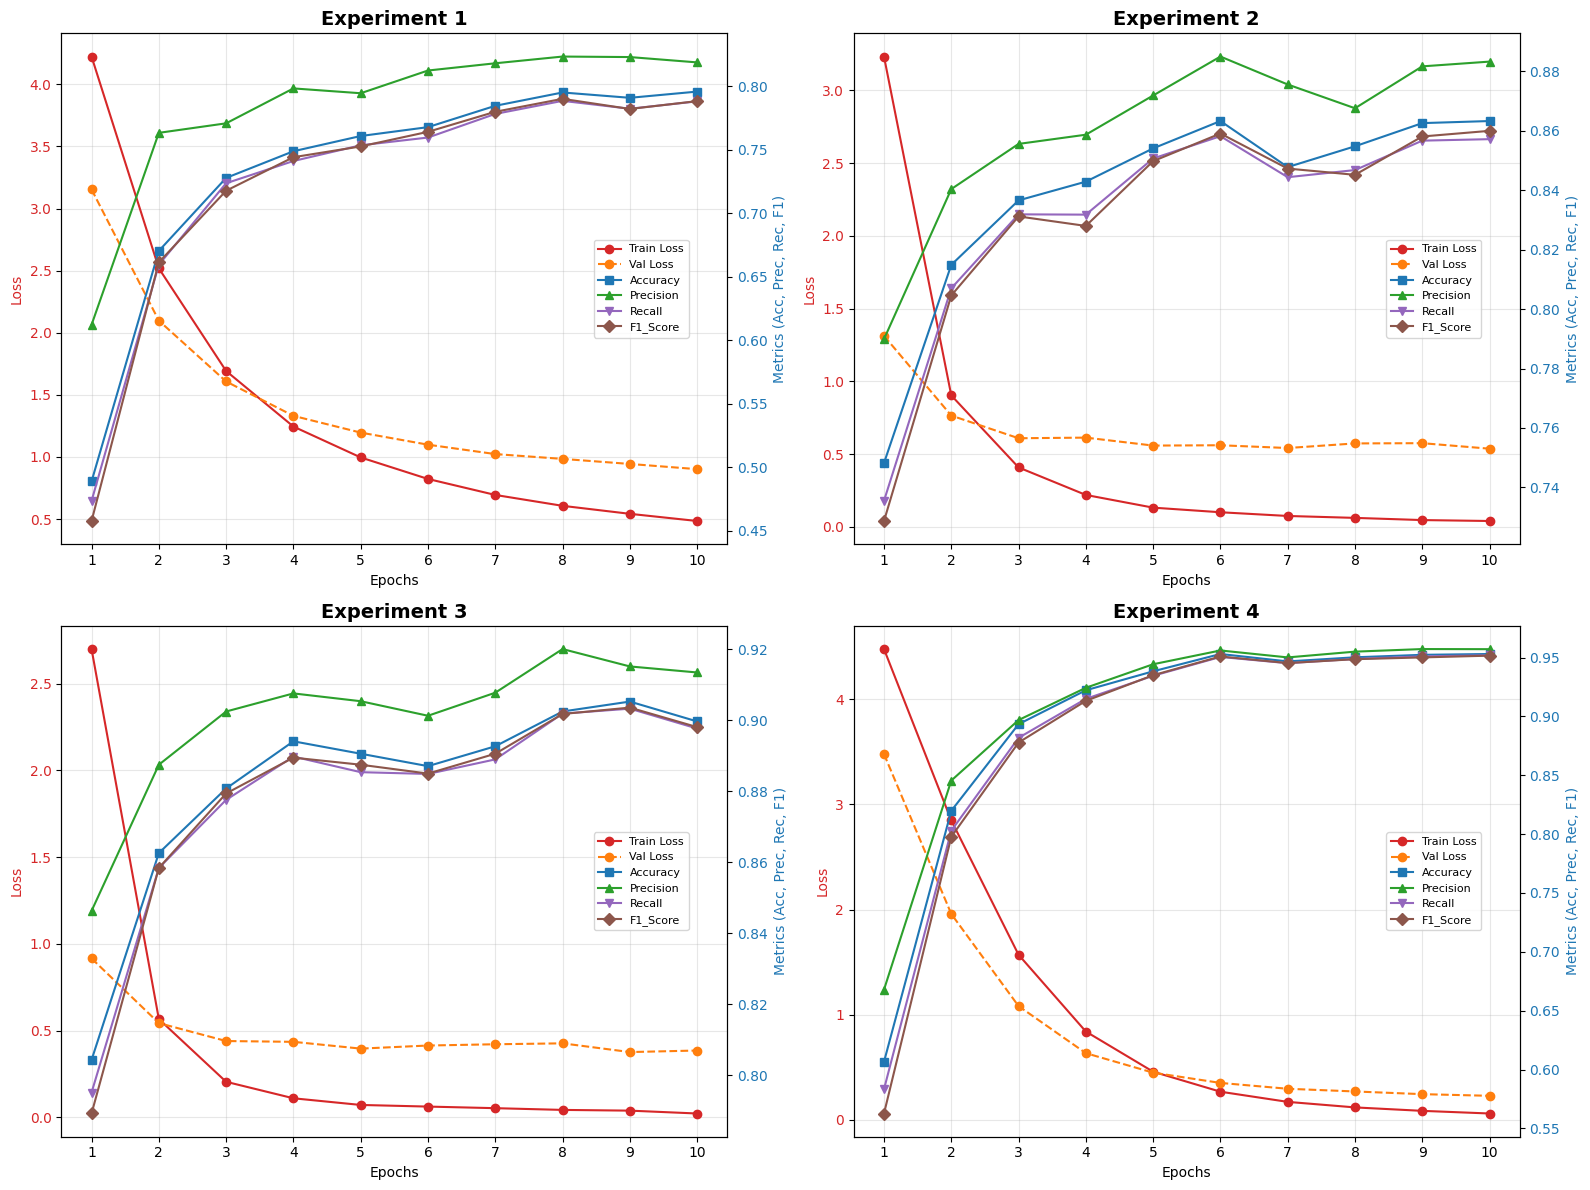

In [32]:
import matplotlib.pyplot as plt
import re

# 제공해주신 원본 로그 데이터
log_data = """
현재 사용 중인 디바이스: cuda:0
실험 2 시작
Epoch 1/10
----------
Train Loss: 4.2242
Val Loss: 3.1541 | Acc: 0.4888 | Precision: 0.6122 | Recall: 0.4734 | F1_Score: 0.4576
Epoch 2/10
----------
Train Loss: 2.5189
Val Loss: 2.0976 | Acc: 0.6704 | Precision: 0.7634 | Recall: 0.6595 | F1_Score: 0.6614
Epoch 3/10
----------
Train Loss: 1.6921
Val Loss: 1.6077 | Acc: 0.7279 | Precision: 0.7709 | Recall: 0.7237 | F1_Score: 0.7178
Epoch 4/10
----------
Train Loss: 1.2448
Val Loss: 1.3310 | Acc: 0.7489 | Precision: 0.7984 | Recall: 0.7412 | F1_Score: 0.7442
Epoch 5/10
----------
Train Loss: 0.9961
Val Loss: 1.1961 | Acc: 0.7609 | Precision: 0.7946 | Recall: 0.7536 | F1_Score: 0.7527
Epoch 6/10
----------
Train Loss: 0.8228
Val Loss: 1.0988 | Acc: 0.7679 | Precision: 0.8125 | Recall: 0.7597 | F1_Score: 0.7642
Epoch 7/10
----------
Train Loss: 0.6941
Val Loss: 1.0232 | Acc: 0.7847 | Precision: 0.8182 | Recall: 0.7783 | F1_Score: 0.7800
Epoch 8/10
----------
Train Loss: 0.6065
Val Loss: 0.9844 | Acc: 0.7952 | Precision: 0.8235 | Recall: 0.7886 | F1_Score: 0.7902
Epoch 9/10
----------
Train Loss: 0.5421
Val Loss: 0.9437 | Acc: 0.7910 | Precision: 0.8231 | Recall: 0.7824 | F1_Score: 0.7822
Epoch 10/10
----------
Train Loss: 0.4843
Val Loss: 0.9018 | Acc: 0.7959 | Precision: 0.8189 | Recall: 0.7882 | F1_Score: 0.7884
학습이 완료되었습니다.
실험 3 시작
Epoch 1/10
----------
Train Loss: 3.2319
Val Loss: 1.3124 | Acc: 0.7482 | Precision: 0.7899 | Recall: 0.7355 | F1_Score: 0.7287
Epoch 2/10
----------
Train Loss: 0.9029
Val Loss: 0.7643 | Acc: 0.8149 | Precision: 0.8404 | Recall: 0.8070 | F1_Score: 0.8046
Epoch 3/10
----------
Train Loss: 0.4078
Val Loss: 0.6084 | Acc: 0.8366 | Precision: 0.8556 | Recall: 0.8319 | F1_Score: 0.8312
Epoch 4/10
----------
Train Loss: 0.2187
Val Loss: 0.6127 | Acc: 0.8429 | Precision: 0.8587 | Recall: 0.8318 | F1_Score: 0.8280
Epoch 5/10
----------
Train Loss: 0.1314
Val Loss: 0.5580 | Acc: 0.8541 | Precision: 0.8719 | Recall: 0.8507 | F1_Score: 0.8498
Epoch 6/10
----------
Train Loss: 0.0997
Val Loss: 0.5602 | Acc: 0.8633 | Precision: 0.8850 | Recall: 0.8582 | F1_Score: 0.8591
Epoch 7/10
----------
Train Loss: 0.0742
Val Loss: 0.5412 | Acc: 0.8478 | Precision: 0.8756 | Recall: 0.8444 | F1_Score: 0.8473
Epoch 8/10
----------
Train Loss: 0.0610
Val Loss: 0.5728 | Acc: 0.8548 | Precision: 0.8676 | Recall: 0.8468 | F1_Score: 0.8452
Epoch 9/10
----------
Train Loss: 0.0460
Val Loss: 0.5745 | Acc: 0.8626 | Precision: 0.8817 | Recall: 0.8567 | F1_Score: 0.8581
Epoch 10/10
----------
Train Loss: 0.0396
Val Loss: 0.5366 | Acc: 0.8633 | Precision: 0.8833 | Recall: 0.8572 | F1_Score: 0.8600
학습이 완료되었습니다.
실험 4 시작
Epoch 1/10
----------
Train Loss: 2.6999
Val Loss: 0.9164 | Acc: 0.8043 | Precision: 0.8463 | Recall: 0.7951 | F1_Score: 0.7892
Epoch 2/10
----------
Train Loss: 0.5667
Val Loss: 0.5434 | Acc: 0.8626 | Precision: 0.8875 | Recall: 0.8584 | F1_Score: 0.8584
Epoch 3/10
----------
Train Loss: 0.2050
Val Loss: 0.4400 | Acc: 0.8808 | Precision: 0.9025 | Recall: 0.8776 | F1_Score: 0.8794
Epoch 4/10
----------
Train Loss: 0.1099
Val Loss: 0.4354 | Acc: 0.8941 | Precision: 0.9076 | Recall: 0.8898 | F1_Score: 0.8895
Epoch 5/10
----------
Train Loss: 0.0715
Val Loss: 0.3963 | Acc: 0.8906 | Precision: 0.9054 | Recall: 0.8854 | F1_Score: 0.8875
Epoch 6/10
----------
Train Loss: 0.0621
Val Loss: 0.4141 | Acc: 0.8871 | Precision: 0.9013 | Recall: 0.8849 | F1_Score: 0.8850
Epoch 7/10
----------
Train Loss: 0.0529
Val Loss: 0.4214 | Acc: 0.8927 | Precision: 0.9078 | Recall: 0.8890 | F1_Score: 0.8906
Epoch 8/10
----------
Train Loss: 0.0429
Val Loss: 0.4267 | Acc: 0.9025 | Precision: 0.9201 | Recall: 0.9019 | F1_Score: 0.9018
Epoch 9/10
----------
Train Loss: 0.0387
Val Loss: 0.3764 | Acc: 0.9053 | Precision: 0.9152 | Recall: 0.9033 | F1_Score: 0.9036
Epoch 10/10
----------
Train Loss: 0.0222
Val Loss: 0.3853 | Acc: 0.8997 | Precision: 0.9135 | Recall: 0.8977 | F1_Score: 0.8981
학습이 완료되었습니다.
현재 사용 중인 디바이스: cuda:0
실험 4 시작
Epoch 1/10
----------
Train Loss: 4.4761
Val Loss: 3.4780 | Acc: 0.6066 | Precision: 0.6679 | Recall: 0.5833 | F1_Score: 0.5627
Epoch 2/10
----------
Train Loss: 2.8477
Val Loss: 1.9583 | Acc: 0.8198 | Precision: 0.8455 | Recall: 0.8029 | F1_Score: 0.7977
Epoch 3/10
----------
Train Loss: 1.5703
Val Loss: 1.0824 | Acc: 0.8934 | Precision: 0.8969 | Recall: 0.8818 | F1_Score: 0.8778
Epoch 4/10
----------
Train Loss: 0.8406
Val Loss: 0.6350 | Acc: 0.9222 | Precision: 0.9243 | Recall: 0.9149 | F1_Score: 0.9132
Epoch 5/10
----------
Train Loss: 0.4588
Val Loss: 0.4496 | Acc: 0.9383 | Precision: 0.9443 | Recall: 0.9345 | F1_Score: 0.9350
Epoch 6/10
----------
Train Loss: 0.2687
Val Loss: 0.3522 | Acc: 0.9530 | Precision: 0.9560 | Recall: 0.9505 | F1_Score: 0.9509
Epoch 7/10
----------
Train Loss: 0.1721
Val Loss: 0.2967 | Acc: 0.9467 | Precision: 0.9501 | Recall: 0.9452 | F1_Score: 0.9453
Epoch 8/10
----------
Train Loss: 0.1195
Val Loss: 0.2710 | Acc: 0.9502 | Precision: 0.9550 | Recall: 0.9488 | F1_Score: 0.9486
Epoch 9/10
----------
Train Loss: 0.0868
Val Loss: 0.2455 | Acc: 0.9523 | Precision: 0.9572 | Recall: 0.9510 | F1_Score: 0.9501
Epoch 10/10
----------
Train Loss: 0.0616
Val Loss: 0.2298 | Acc: 0.9530 | Precision: 0.9571 | Recall: 0.9519 | F1_Score: 0.9516
학습이 완료되었습니다.
"""

# 정규표현식을 이용한 데이터 파싱
experiments_data = []
# "실험 N 시작"을 기준으로 문자열 분할
chunks = re.split(r'실험 \d+ 시작', log_data)[1:]

for chunk in chunks:
    experiments_data.append({
        'train_loss': [float(x) for x in re.findall(r'Train Loss:\s*([\d\.]+)', chunk)],
        'val_loss': [float(x) for x in re.findall(r'Val Loss:\s*([\d\.]+)', chunk)],
        'acc': [float(x) for x in re.findall(r'Acc:\s*([\d\.]+)', chunk)],
        'precision': [float(x) for x in re.findall(r'Precision:\s*([\d\.]+)', chunk)],
        'recall': [float(x) for x in re.findall(r'Recall:\s*([\d\.]+)', chunk)],
        'f1': [float(x) for x in re.findall(r'F1_Score:\s*([\d\.]+)', chunk)]
    })

# 시각화 설정 (2x2 서브플롯)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
epochs = range(1, 11)

for i, exp in enumerate(experiments_data):
    ax1 = axes[i]
    ax2 = ax1.twinx()  # 이중 Y축 생성

    # Loss 플롯 (왼쪽 축)
    l1 = ax1.plot(epochs, exp['train_loss'], color='tab:red', linestyle='-', marker='o', label='Train Loss')
    l2 = ax1.plot(epochs, exp['val_loss'], color='tab:orange', linestyle='--', marker='o', label='Val Loss')
    ax1.set_xlabel('Epochs', fontsize=10)
    ax1.set_ylabel('Loss', color='tab:red', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='tab:red')

    # Metrics 플롯 (오른쪽 축)
    l3 = ax2.plot(epochs, exp['acc'], color='tab:blue', linestyle='-', marker='s', label='Accuracy')
    l4 = ax2.plot(epochs, exp['precision'], color='tab:green', linestyle='-', marker='^', label='Precision')
    l5 = ax2.plot(epochs, exp['recall'], color='tab:purple', linestyle='-', marker='v', label='Recall')
    l6 = ax2.plot(epochs, exp['f1'], color='tab:brown', linestyle='-', marker='D', label='F1_Score')
    ax2.set_ylabel('Metrics (Acc, Prec, Rec, F1)', color='tab:blue', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    # X축 눈금 설정
    ax1.set_xticks(epochs)

    # 범례 합치기
    lines = l1 + l2 + l3 + l4 + l5 + l6
    labels = [line.get_label() for line in lines]
    # 그래프 겹침을 방지하기 위해 범례를 중앙 우측 여백에 배치
    ax1.legend(lines, labels, loc='center right', fontsize=8, bbox_to_anchor=(0.95, 0.5))

    # 타이틀 설정 (요청하신 대로 1, 2, 3, 4 순서 매핑)
    ax1.set_title(f'Experiment {i+1}', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
import torch
import os

# 구글 드라이브 내 저장할 폴더 및 파일 경로 지정
save_dir = '/content/drive/MyDrive/Model_Weights'
os.makedirs(save_dir, exist_ok=True) # 폴더가 없으면 생성

save_path = os.path.join(save_dir, 'experiment_model_weights.pth')

# 모델의 state_dict만 추출하여 저장
torch.save(model.state_dict(), save_path)
print(f"가중치가 구글 드라이브에 저장되었습니다: {save_path}")

가중치가 구글 드라이브에 저장되었습니다: /content/drive/MyDrive/Model_Weights/experiment_model_weights.pth
